In [19]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [21]:
df = pd.read_csv('../dados/df_regressao.csv')

# Filtrando apenas os meses de Verão (Dezembro, Janeiro, Fevereiro)
meses_verao = [12, 1, 2]
df_verao = df[df['mes'].isin(meses_verao)]

# Tirar a média dos verões de 2020 ate 2023 para cada bairro
df_verao_bairros = df_verao.groupby('bairro').mean(numeric_only=True).reset_index()
# Removendo colunas que não fazem sentido como média
df_verao_bairros = df_verao_bairros.drop(columns=['ano', 'mes'])

# Normalizando os Dados

In [22]:
# Normalizando os valores para ficarem entre 0 e 1
scaler = MinMaxScaler()
# Selecionando as colunas do df_verao_bairros
colunas_vulnerabilidade = ['temp_max_media', 'percentual_verde', 'umidade_min_media']
dados_normalizados = scaler.fit_transform(df_verao_bairros[colunas_vulnerabilidade])

# Criando um DataFrame auxiliar com os dados normalizados
df_norm = pd.DataFrame(dados_normalizados, columns=colunas_vulnerabilidade)

df_norm.head()

,temp_max_media,percentual_verde,umidade_min_media
0,0.932982,0.524696,0.260567
1,0.000000,0.015399,0.657457
2,0.771173,0.018291,0.393034
3,0.576025,0.173059,0.600095
4,0.507020,0.231876,0.693989


# Calculando nosso Índice de Vulnerabilidade Térmica (IVT)

In [23]:
# Definindo os pesos 
w_temp = 0.5
w_verde = 0.3
w_umidade = 0.2

# Quanto MENOS verde, MAIS vulnerável. Por isso usamos (1 - Verde)
df_verao_bairros['IVT'] = (
    (df_norm['temp_max_media'] * w_temp) + 
    ((1 - df_norm['percentual_verde']) * w_verde) + 
    ((1 - df_norm['umidade_min_media']) * w_umidade)
)

df_verao_bairros['IVT']

0      0.756969
1      0.363889
2      0.801493
3      0.616076
4      0.545149
         ...   
114    0.805712
115    0.648714
116    0.781144
117    0.865702
118    0.633519
Name: IVT, Length: 119, dtype: float64

# Clusters

In [36]:
# Rodando o K-Means com, por exemplo, 3 grupos
kmeans = KMeans(n_clusters=3, random_state=42)
df_verao_bairros['cluster'] = kmeans.fit_predict(dados_normalizados)

nomes_clusters = {
    '0': 'Emergência Térmica',
    '1': 'Zonas de Resiliência',
    '2': 'Vulnerabilidade Urbana'
}

# Criando a coluna com os nomes (garantindo que o cluster seja string para o map)
df_verao_bairros['categoria_climatica'] = df_verao_bairros['cluster'].astype(str).map(nomes_clusters)

# Conferindo o resultado
display(df_verao_bairros[['bairro', 'cluster', 'categoria_climatica', 'IVT']].sort_values(by='IVT', ascending=False).head(10))


df_verao_bairros.head()

,bairro,cluster,categoria_climatica,IVT
48,Inhoaíba,0,Emergência Térmica,0.922292
87,Ricardo de Albuquerque,0,Emergência Térmica,0.913553
98,Senador Vasconcelos,0,Emergência Térmica,0.887365
117,Vista Alegre,0,Emergência Térmica,0.865702
90,Rocha Miranda,0,Emergência Térmica,0.864748
111,Vaz Lobo,0,Emergência Térmica,0.857877
106,Tomás Coelho,0,Emergência Térmica,0.853034
70,Padre Miguel,0,Emergência Térmica,0.850485
62,Madureira,0,Emergência Térmica,0.849318
14,Campinho,0,Emergência Térmica,0.847943


,bairro,percentual_verde,lat,lon,temp_max_media,temp_max_abs,chuva_total,umidade_min_media,IVT,cluster,categoria_climatica
0,Acari,17.639075,-22.8450,-43.394,31.181773,37.025000,218.408333,58.179144,0.756969,0,Emergência Térmica
1,Alto da Boa Vista,0.548378,-22.9460,-43.270,26.816831,32.783333,179.875000,63.933329,0.363889,1,Zonas de Resiliência
2,Anchieta,0.645406,-22.8180,-43.344,30.424752,36.508333,187.025000,60.099674,0.801493,0,Emergência Térmica
3,Andaraí,5.839019,-22.9148,-43.254,29.511757,35.516667,183.116667,63.101687,0.616076,2,Vulnerabilidade Urbana
4,Anil,7.812770,-22.9380,-43.339,29.188917,35.150000,179.875000,64.462985,0.545149,2,Vulnerabilidade Urbana


# Visualização com PCA

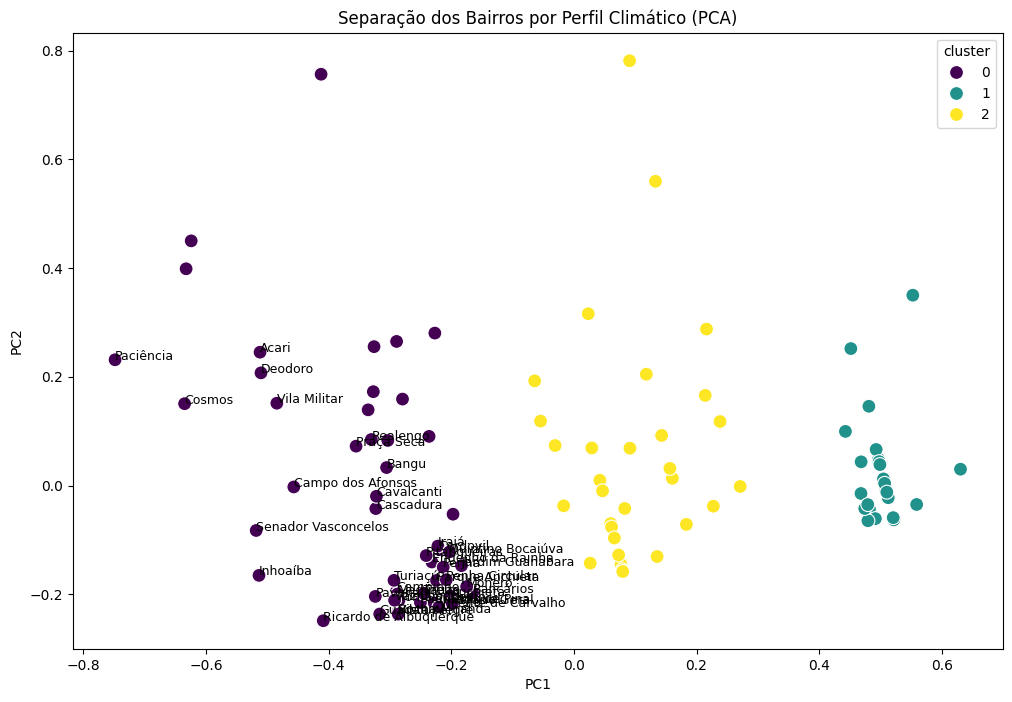

In [40]:
# Aplicando o PCA para reduzir para 2 dimensões (PC1 e PC2)
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(dados_normalizados)

# Criando um DataFrame para o plot
df_pca = pd.DataFrame(data = componentes_principais, columns = ['PC1', 'PC2'])
df_pca['cluster'] = df_verao_bairros['cluster'].values
df_pca['bairro'] = df_verao_bairros['bairro'].values

# Plotando
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_pca, palette='viridis', s=100)

# Adicionar nomes dos bairros mais críticos
for i in range(df_pca.shape[0]):
    if df_verao_bairros.iloc[i]['IVT'] > 0.75: # Destaque para os mais vulneráveis
        plt.text(df_pca.PC1[i], df_pca.PC2[i], df_pca.bairro[i], fontsize=9)

plt.title('Separação dos Bairros por Perfil Climático (PCA)')
plt.savefig('../assets/clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
# Mostra os bairros com maior IVT dentro de cada cluster
for i in range(3): 
    print(f"\n--- CLUSTER {i} ---")
    bairros_do_cluster = df_verao_bairros[df_verao_bairros['cluster'] == i]
    # Ordena para ver os mais críticos de cada grupo primeiro
    top_bairros = bairros_do_cluster.sort_values(by='IVT', ascending=False).head(50)
    print(top_bairros[['bairro', 'IVT', 'temp_max_media']].to_string(index=False))


--- CLUSTER 0 ---
                bairro      IVT  temp_max_media
              Inhoaíba 0.922292       31.485931
Ricardo de Albuquerque 0.913553       31.232493
   Senador Vasconcelos 0.887365       31.385931
          Vista Alegre 0.865702       30.948126
         Rocha Miranda 0.864748       30.948126
              Vaz Lobo 0.857877       30.948126
          Tomás Coelho 0.853034       30.895794
          Padre Miguel 0.850485       30.940085
             Madureira 0.849318       30.895794
              Campinho 0.847943       30.895794
               Turiaçú 0.841653       30.895794
             Guadalupe 0.841609       30.508199
     Campo dos Afonsos 0.833156       31.181773
                Pavuna 0.831660       30.508199
                  Tauá 0.830519       30.749688
             Paciência 0.830103       31.495316
               Colégio 0.826581       30.649688
   Vicente de Carvalho 0.824138       30.599440
         Vigário Geral 0.805712       30.424752
          Brás de Pin

# Ranking de Vulnerabilidade

In [ ]:
df_verao_bairros['PC1'] = df_pca['PC1'].values
df_verao_bairros['PC2'] = df_pca['PC2'].values

# 1. Criando o ranking: ordenando pelo IVT (maior para o menor)
ranking_vulnerabilidade = df_verao_bairros.sort_values(by='IVT', ascending=False)

# 2. Adicionando 'PC1', 'PC2', 'lat' e 'lon' aqui para o front ter TUDO em um arquivo só
colunas_front = [
    'bairro', 'IVT', 'categoria_climatica', 
    'temp_max_media', 'percentual_verde', 
    'lat', 'lon', 'PC1', 'PC2'
]

tabela_vulnerabilidade = ranking_vulnerabilidade[colunas_front]

# 3. Salvando em CSV (opcional, bom para tabelas simples)
tabela_vulnerabilidade.to_csv('../dados/ranking_vulnerabilidade.csv', index=False, encoding='utf-8')

# 4. Salvando em JSON (O ARQUIVO MESTRE DO FRONT-END)
# Com PC1, PC2, lat e lon, eles fazem o mapa E o gráfico de PCA com um arquivo só
tabela_vulnerabilidade.to_json('../dados/ranking_vulnerabilidade.json', orient='records', indent=4)

print("Arquivos de ranking gerados com sucesso na pasta 'dados'!")

Arquivos de ranking gerados com sucesso na pasta 'dados'!


# Gerando um "mapa" de distribuicao espacial dos clusters

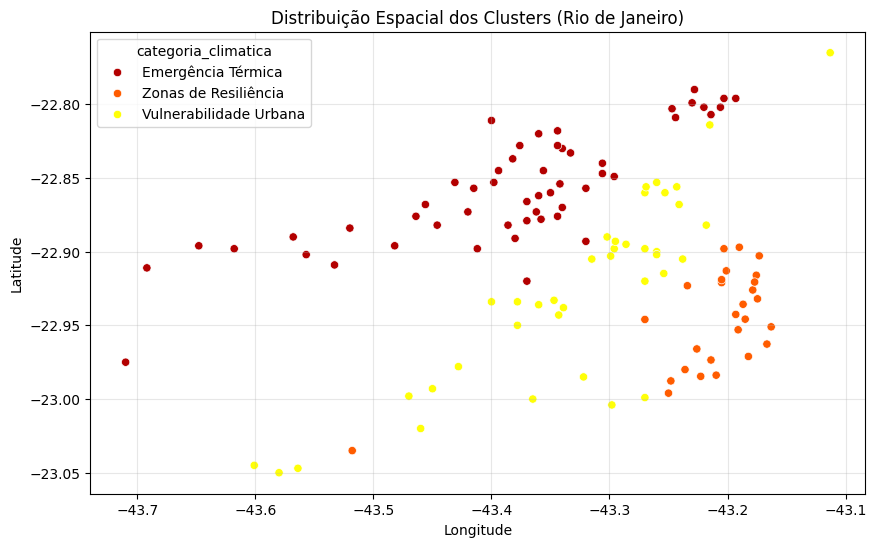

In [45]:
plt.figure(figsize=(10, 6))
# Usando as coordenadas como eixos X e Y
sns.scatterplot(data=df_verao_bairros, x='lon', y='lat', hue='categoria_climatica', palette='hot')

plt.title("Distribuição Espacial dos Clusters (Rio de Janeiro)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.3)
plt.savefig('../assets/distribuicao_espacial_clusters.png', dpi=300)
plt.show()